- Author: Bertin Iradukunda
- Email: bi2067@nyu.edu

## Project: Avazu Click Through Rate (CTR) challenge

 - Click-through rate (CTR) prediction is a fundamental problem in online advertising, where the objective is to estimate the probability that a user will click on a given advertisement. The Avazu CTR Prediction Challenge provides a large-scale, highly sparse dataset composed primarily of categorical features describing users, ads, devices, and contextual information. This setting makes CTR prediction particularly challenging due to extreme dimensionality, sparsity, and the importance of capturing complex feature interactions.

- Accurate CTR prediction has direct implications across multiple domains. In digital advertising, it enables more effective ad targeting, improved user engagement, and optimized revenue through better bidding strategies. Beyond advertising, similar modeling techniques apply to recommendation systems, search ranking, and personalized content delivery, where predicting user behavior is critical.
- We'll use a range of machine learning models, starting with baseline methods such as Logistic Regression and gradient-boosted trees. These models are enhanced with feature engineering techniques to improve performance on high-dimensional data. To further capture complex interactions, the approach is extended with Field-Aware Factorization Machines and deep NN (MLP), which are better suited for learning structured relationships in sparse feature spaces.

In [1]:
import sys
from zipfile import ZipFile
import os.path as op
try:
    from urllib.request import urlretrieve
except ImportError:  # Python 2 compat
    from urllib import urlretrieve

AVAZU_URL = "https://bianchi.wp.imt.fr/files/2019/05/train-1000000.zip"
AVAZU_FILENAME = AVAZU_URL.rsplit('/', 1)[1]


if not op.exists(AVAZU_FILENAME):
    print('Downloading %s to %s...' % (AVAZU_URL, AVAZU_FILENAME))
    urlretrieve(AVAZU_URL, AVAZU_FILENAME)
    ZipFile(AVAZU_FILENAME).extractall('.')

In [2]:
ZipFile(AVAZU_FILENAME).extractall('.')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
%matplotlib inline

You can find more on the Data description here: https://www.kaggle.com/c/avazu-ctr-prediction/data  


Load train data

In [4]:
df = pd.read_csv('train-1000000')

In [5]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


Import test data

In [7]:
input_directory = "/content/drive/MyDrive/Machine-Learning_Paris/Project/"
test_df = pd.read_csv(input_directory + "test.csv")

### 1. Exploratory Data Analysis (EDA)

This section aims to systematically examine the dataset to understand individual feature distributions and identify underlying relationships between variables. These insights will provide the empirical foundation for our feature engineering strategy and model selection during the development phase.

In [ ]:
df.head(15)

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,3.983206e+18,0,14102915,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,...,1,2,4687,320,50,423,2,39,100148,32
1,7.756884e+18,0,14103007,1002,0,cb809abf,74acf31a,50e219e0,ecad2386,7801e8d9,...,0,0,17894,320,50,2039,2,39,100077,32
2,6.941774e+17,0,14102711,1005,0,85f751fd,c4e18dd6,50e219e0,e9739828,df32afa9,...,1,0,22684,320,50,2619,1,163,100055,71
3,2.664154e+18,1,14102903,1005,0,85f751fd,c4e18dd6,50e219e0,a5184c22,b8d325c3,...,1,0,23222,320,50,2676,0,35,100176,221
4,1.480510e+19,0,14102902,1005,1,791b5571,fd13bc73,f028772b,ecad2386,7801e8d9,...,1,0,8330,320,50,761,3,175,100081,23
5,1.591127e+19,0,14102700,1005,0,85f751fd,c4e18dd6,50e219e0,febd1138,82e27996,...,1,0,21611,320,50,2480,3,297,100111,61
6,4.149473e+18,0,14102408,1010,1,85f751fd,c4e18dd6,50e219e0,03a08c3f,7801e8d9,...,4,3,15704,320,50,1722,0,35,100084,79
7,1.085379e+19,0,14102904,1005,0,85f751fd,c4e18dd6,50e219e0,a5184c22,b8d325c3,...,1,0,23224,320,50,2676,0,35,100176,221
8,2.629918e+18,0,14102513,1010,1,85f751fd,c4e18dd6,50e219e0,8486dd4e,7801e8d9,...,4,0,17875,320,50,2036,3,47,-1,156
9,1.419062e+19,0,14102600,1010,1,85f751fd,c4e18dd6,50e219e0,04f2be5f,7801e8d9,...,4,3,22552,320,50,2602,0,163,100084,182


In [ ]:
df.shape

(1000000, 24)

The dataset contains 1 millions ads impressions (examples) with 24 features which are listed below

In [ ]:
df.columns

Index(['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain',
       'site_category', 'app_id', 'app_domain', 'app_category', 'device_id',
       'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14',
       'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1000000 non-null  float64
 1   click             1000000 non-null  int64  
 2   hour              1000000 non-null  int64  
 3   C1                1000000 non-null  int64  
 4   banner_pos        1000000 non-null  int64  
 5   site_id           1000000 non-null  object 
 6   site_domain       1000000 non-null  object 
 7   site_category     1000000 non-null  object 
 8   app_id            1000000 non-null  object 
 9   app_domain        1000000 non-null  object 
 10  app_category      1000000 non-null  object 
 11  device_id         1000000 non-null  object 
 12  device_ip         1000000 non-null  object 
 13  device_model      1000000 non-null  object 
 14  device_type       1000000 non-null  int64  
 15  device_conn_type  1000000 non-null  int64  
 16  C

Columns like C1, C14-C21, and device_type are currently int64, but they are anonymized discrete categories, not continuous measurements

Next, let's evaluate the proportion of the target class in the data

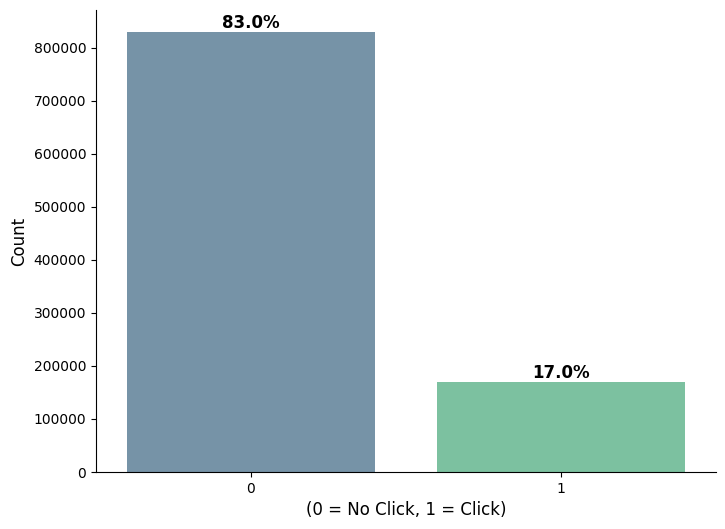

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))

# Create the countplot
ax = sns.countplot(x='click', data=df, palette='viridis', hue= 'click', legend = False, alpha = 0.7)

# Calculate percentages and add labels
total = len(df['click'])
for p in ax.patches:
    # Calculate percentage
    percentage = f'{100 * p.get_height() / total:.1f}%'

    # Annotate at the top of the bar
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')
sns.despine()

plt.xlabel('(0 = No Click, 1 = Click)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

- The dataset is clearly imbalanced, with 83% non clicks, metrics like accuracy is a useless metric here. A model that is 83% accurate could actually be failing to find a single person who clicks.
- There are almost five times more data on what a "Non-Clicker" looks like than a "Clicker." Thus, we need high quality features to help the model distinguish classes. Also we can create new synthetic examples, using techniques like 'SMOTE'

In [ ]:
# Unique values per feature
cardinality = df.nunique().sort_values(ascending=False)
print("Unique Values):\n")
print(cardinality)

Unique Values):

id                  1000000
device_ip            555248
device_id            150501
device_model           5168
app_id                 3157
site_domain            2871
site_id                2651
C14                    2243
C17                     420
hour                    240
app_domain              198
C20                     163
C19                      66
C21                      60
app_category             26
site_category            22
C16                       9
C15                       8
C1                        7
banner_pos                7
device_type               5
device_conn_type          4
C18                       4
click                     2
dtype: int64


- The id is a unique identifier and therefore, it carries no predictive power and should be dropped.
- device_ip (555k) and device_id (150k) are extremely high-cardinality. We cannot one-hot encode these; we will need different tecnique like Frequency Encoding to capture their signal.
- hour has 240 unique values. Since the Avazu data covers 10 days, this confirms the format is YYMMDDHH. We can split this into Day of Week and Hour of Day to find cyclic patterns.

In [ ]:
# Check if CTR changes based on how often an IP appears
ip_counts = df.groupby('device_ip')['click'].agg(['count', 'mean'])
print(ip_counts.sort_values(by='count', ascending=False).head(10))

           count      mean
device_ip                 
6b9769f2    5130  0.229825
431b3174    3291  0.209663
2f323f36    2197  0.091488
930ec31d    2196  0.091075
285aa37d    2181  0.100871
009a7861    2165  0.099307
af9205f9    2148  0.099162
af62faf4    2112  0.095644
6394f6f6    2103  0.086543
d90a7774    2018  0.108028


- We see that the top two IPs (6b9769f2 and 431b3174) have a CTR of around 21–23% which implies some "locations" (IPs) are more likely to click than others.
- A tiny fraction of IPs accounts for a large chunk of the data. These IPs could represent public Wi-Fi at an airport or a cellular gateway where thousands of different users share one IP.

In [ ]:
# Identify the most frequent device_id
top_devices = df.groupby('device_id')['click'].agg(['count', 'mean'])
print(top_devices.sort_values(by='count', ascending=False).head(10))

            count      mean
device_id                  
a99f214a   824918  0.174347
0f7c61dc      512  0.765625
c357dbff      481  0.667360
936e92fb      366  0.071038
afeffc18      242  0.247934
987552d1      103  0.000000
d857ffbb       98  0.234694
cef4c8cc       93  0.182796
b09da1c4       91  0.153846
28dc8687       86  0.000000


- One thing stands out, we see that one device_id (a99f214a) appears 82.5%. Strange, right? Most likely,  it is anonymous or a placeholder for devices whose specific identity couldn't be tracked.
- So, this specific device_id tell the model nothing about the specific user's interactions with the ad. Instead, the model should focus on Context.

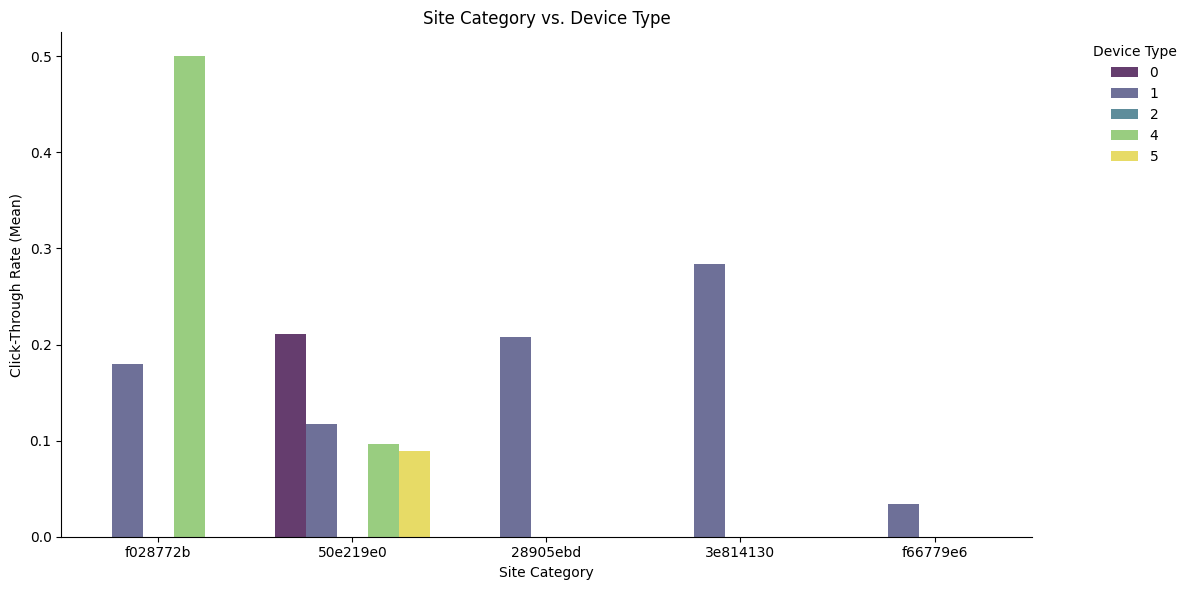

In [ ]:

#   top 5 most frequent site categories
top_sites = df['site_category'].value_counts().nlargest(5).index
df_sub = df[df['site_category'].isin(top_sites)]

#  grouped bar chart showing the mean of 'click'
plt.figure(figsize=(12, 6))
sns.barplot(x='site_category', y='click', hue='device_type', data=df_sub,
            palette='viridis', alpha=0.8, errorbar=None)

sns.despine()

plt.title('Site Category vs. Device Type', fontsize=12)
plt.ylabel('Click-Through Rate (Mean)')
plt.xlabel('Site Category')
plt.legend(title='Device Type', bbox_to_anchor=(1.05, 1), loc='upper left', frameon = False)

plt.tight_layout()
plt.show()

- Looking at site categories like 3e817013 or f028f304. You see massive spikes for specific devices.

   - You cannot treat site category and device type as independent features.
   - Their interaction matters — a lot.

- In some categories (like the one on the far left), all bars are relatively high. In others, like the top right category, the CTR is nearly zero across the board. If a site is bad for ads, it doesn't matter what device the user has, they won't click. So, site category matters.

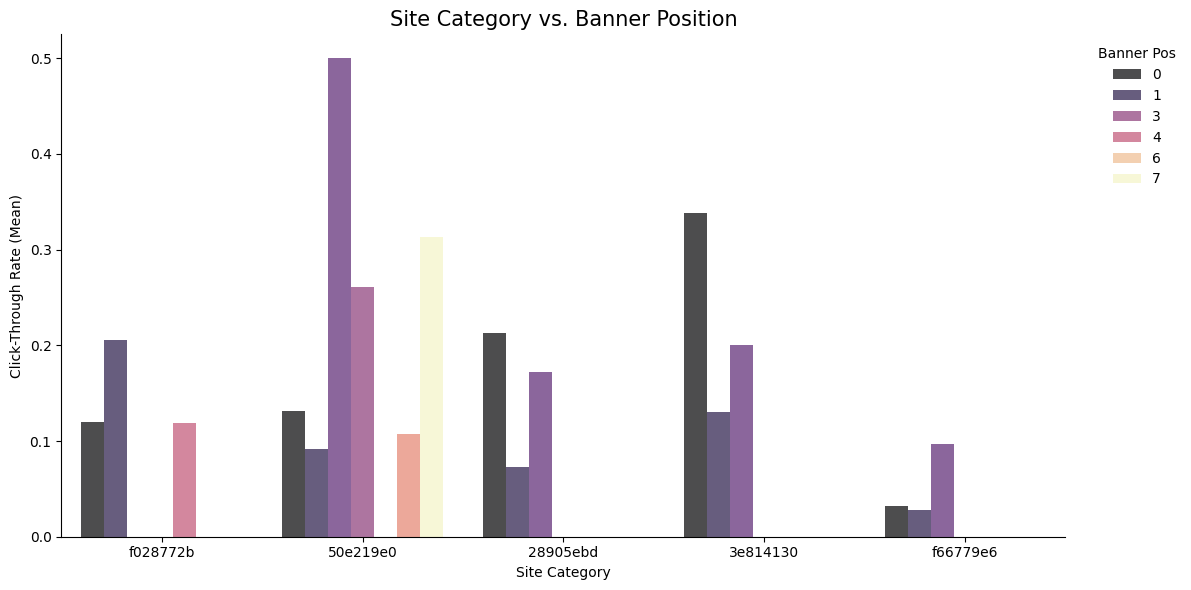

In [ ]:
#  Filter for the top 5 site categories by frequency
top_sites = df['site_category'].value_counts().nlargest(5).index
df_filtered = df[df['site_category'].isin(top_sites)]

# Create the grouped bar chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='site_category', y='click', hue='banner_pos',
                 data=df_filtered, palette='magma', alpha=0.7, errorbar=None)

sns.despine() # Removes top and right frames
plt.legend(title='Banner Pos', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.title('Site Category vs. Banner Position', fontsize=15)
plt.ylabel('Click-Through Rate (Mean)')
plt.xlabel('Site Category')
plt.tight_layout()
plt.show()

- The effect of banner position on CTR varies significantly across site categories. While some positions, e.g., 0 and 3, perform well in certain categories, no single position consistently yields the highest CTR.
- The ranking and magnitude of CTR across banner positions change depending on the site category, indicating that the impact of banner placement is context-dependent rather than uniform. Thus, the interaction between the banner position and site category matters.

Next, we explore the effects of timing on the CTR, and the likely interactions between it and the site category.

Since the dataset spans only 10 consecutive days, extracting the full date provides limited additional value. Instead, we focus on the day within the period and the hour of the day, as these are more relevant for capturing temporal patterns in user behavior and click activity.

In [8]:
import datetime
# Feature Engineering: Extracting the Hour, and the Day
dt = pd.to_datetime(df['hour'], format='%y%m%d%H')

df['day'] = dt.dt.weekday
df['hour_of_day'] = dt.dt.hour

test_df['day'] = dt.dt.weekday
test_df['hour_of_day'] = dt.dt.hour

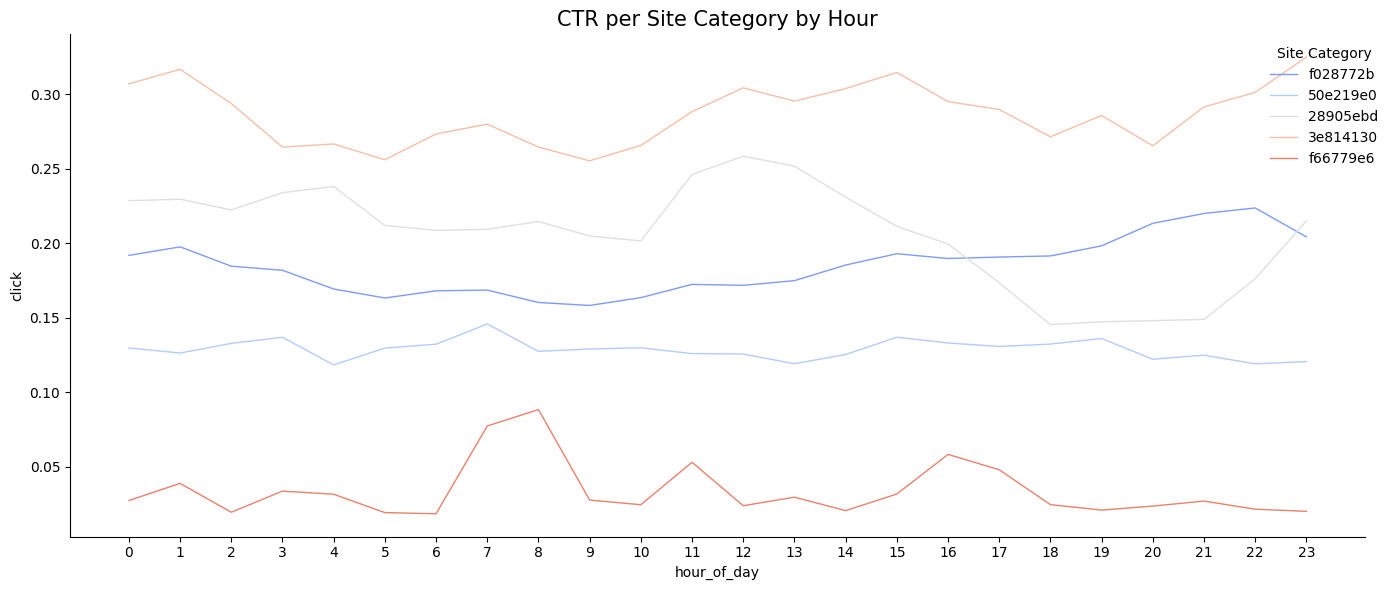

In [9]:
#  Filter for Top 5 Site Categories
top_sites = df['site_category'].value_counts().nlargest(5).index
df_top = df[df['site_category'].isin(top_sites)]

#  Line Plot of CTR over Time
plt.figure(figsize=(14, 6))
sns.lineplot(x='hour_of_day', y='click', hue='site_category', data=df_top,
             palette='coolwarm', linewidth=1, alpha=0.9, errorbar= None)

sns.despine()
plt.legend(title='Site Category', frameon=False, bbox_to_anchor=(1.02, 1), loc='upper right')
plt.title('CTR per Site Category by Hour', fontsize=15)
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

- Almost every single line dips significantly between 3:00 AM to 8:00 AM. This represents a period of general inactivity. Not only are there likely fewer impressions, but the intent of the users who are online is much lower.
- Some lines, show upward trends starting around Hour 10 to 15 and from 18 to 23. This points to after-work or evening relaxation behavior. Therefore, an interaction term combining hour  and these specific site_categories will likely yield a strong positive signal.
- For some categories like 50e219e0, the trend remains relatively flat throughout the day which indicates time of day matters less here.

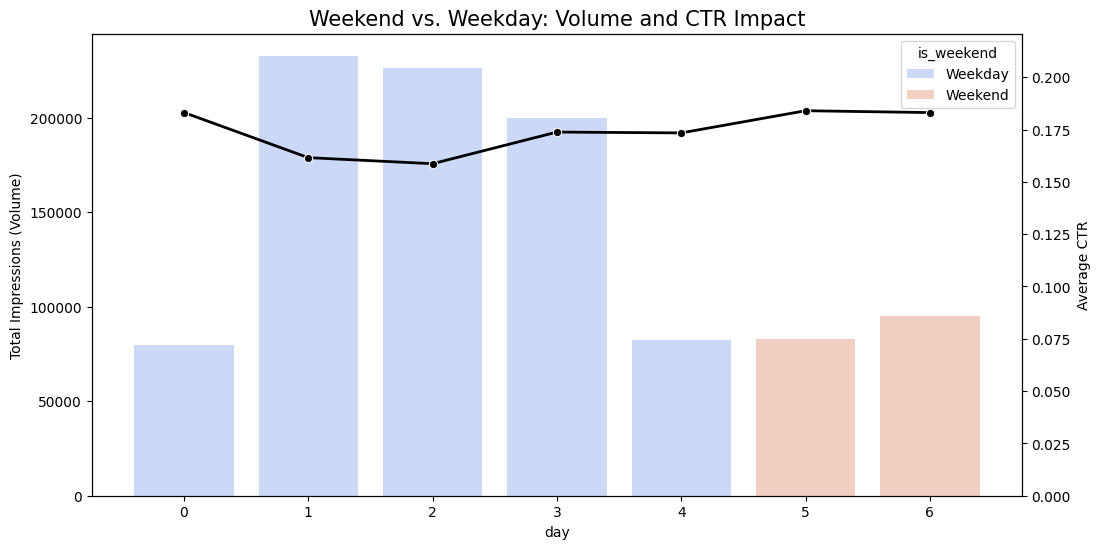

In [10]:


#  Flag Weekends (assuming 'day' is 0-6 where 5=Sat, 6=Sun)
df['is_weekend'] = df['day'].apply(lambda x: 'Weekend' if x in [5, 6] else 'Weekday')
test_df['is_weekend'] = test_df['day'].apply(lambda x: 'Weekend' if x in [5, 6] else 'Weekday')
#  Group by Day to see the trend
daily_stats = df.groupby(['day', 'is_weekend'])['click'].agg(['count', 'mean']).reset_index()

#  Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Volume
sns.barplot(x='day', y='count', hue='is_weekend', data=daily_stats, palette='coolwarm', ax=ax1, alpha=0.7)
ax1.set_ylabel('Total Impressions (Volume)')
ax1.set_title('Weekend vs. Weekday: Volume and CTR Impact', fontsize=15)

# Line chart for CTR (on the second Y-axis)
ax2 = ax1.twinx()
sns.lineplot(x=range(len(daily_stats)), y=daily_stats['mean'], marker='o', color='black', ax=ax2, linewidth=2)
ax2.set_ylabel('Average CTR')
ax2.set_ylim(0, daily_stats['mean'].max() * 1.2) #

plt.show()

- Weekends have lower traffic but higher CTR, suggesting stronger user engagement, but this effect may be partly driven by shifts in traffic composition rather than purely behavioral change.

In [ ]:
print("Top 3 Site IDs:")
print(df['site_id'].value_counts().head(3))

print("\nTop 3 App IDs:")
print(df['app_id'].value_counts().head(3))
print("\nTop 3 Site Domain:")
print(df['site_domain'].value_counts().head(3))

print("\nTop 3 App Domain:")
print(df['app_domain'].value_counts().head(3))

Top 3 Site IDs:
site_id
85f751fd    360911
1fbe01fe    159924
e151e245     65231
Name: count, dtype: int64

Top 3 App IDs:
app_id
ecad2386    639089
92f5800b     38643
e2fcccd2     28008
Name: count, dtype: int64

Top 3 Site Domain:
site_domain
c4e18dd6    374158
f3845767    159924
7e091613     82263
Name: count, dtype: int64

Top 3 App Domain:
app_domain
7801e8d9    673864
2347f47a    129388
ae637522     46638
Name: count, dtype: int64


- From above numbers, some site id and app id accounts for majority of data. Given that the ad is either shown on app or website, it is  most likely that,  when an ad is shown inside an App, the site_id is set to the dummy value 85f751fd. If it's on a mobile website, the app_id is set to the dummy value ecad2386.

- To capture where the ad is actually shown, we create a new environment feature

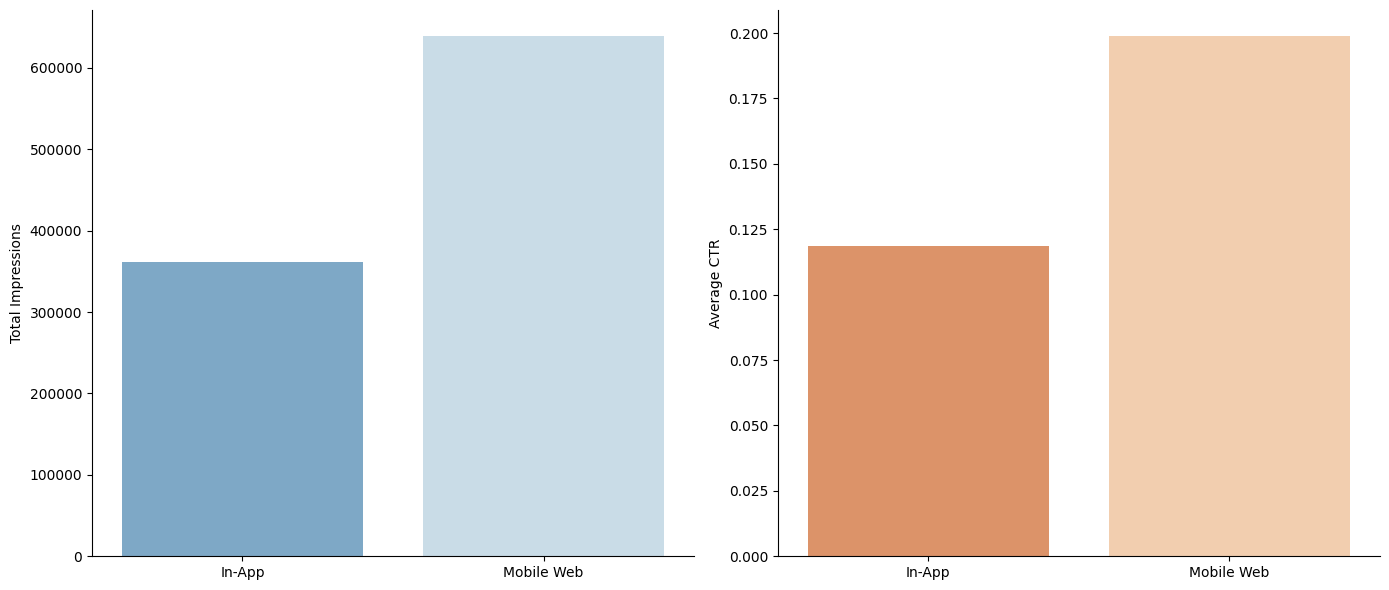

In [11]:
# find the dummy IDs (The most frequent value in the column)
dummy_site_id = df['site_id'].mode()[0]
dummy_app_id = df['app_id'].mode()[0]

def determine_environment(row):
    # If the site_id is the default/dummy, they are in an App
    if row['site_id'] == dummy_site_id:
        return 'In-App'
    # If the app_id is the default/dummy, they are on the Mobile Web
    elif row['app_id'] == dummy_app_id:
        return 'Mobile Web'
    # Fallback for rare cases where both or neither are dummy values
    else:
        return 'Mixed/Unknown'

# Apply the logic along the rows
df['environment'] = df.apply(determine_environment, axis=1)
test_df['environment'] = test_df.apply(determine_environment, axis=1)
# Calculate the Stats (Volume & CTR)
env_stats = df.groupby('environment')['click'].agg(
    Volume='count',
    CTR='mean'
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Chart: Volume ---
sns.barplot(x='environment', y='Volume', data=env_stats, hue= 'environment',
            palette='Blues_r', alpha = 0.7, ax=axes[0])
axes[0].set_ylabel('Total Impressions')
axes[0].set_xlabel('')

# --- Right Chart: CTR ---
sns.barplot(x='environment', y='CTR', data=env_stats, hue = 'environment',
            palette='Oranges_r', alpha = 0.7, ax=axes[1])
axes[1].set_ylabel('Average CTR')
axes[1].set_xlabel('')

sns.despine()
plt.tight_layout()
plt.show()

- users are both more frequently exposed to ads on the Mobile Web and are significantly more likely to click them compared to In-App environments. The difference matters.

### Feature Engineering

#### Handling dummy device id ( untracked devices)

As we discovered in the EDA section, one device id accounts for approximately 82% of the data, which is peculiar and functions more as a placeholder than an actual ID.

So, in this section, we engineer a new feature, user-id, by combining device-ip and device-model whenever the device-id is a placeholder. With this method, we break down the massive anonymous cluster into distinct  users, allowing the model to capture individual behavior patterns that were previously hidden in the noise


In [12]:

# identify the dummy device_id
dummy_device_id = df['device_id'].mode()[0]

# If the condition is true (it IS the dummy ID), we create the composite ID by
# concatenating the IP and model

df['user_id'] = np.where(df['device_id'] == dummy_device_id,
                         df['device_ip'] + df['device_model'],
                         df['device_id'])
test_df['user_id'] = np.where(test_df['device_id'] == dummy_device_id,
                              test_df['device_ip'] + test_df['device_model'],
                         test_df['device_id'])

# df = df.drop(columns=['device_id'])

print(f'Unique user id: {df['user_id'].nunique()}') # Check how many unique user IDs you've now created

Unique user id: 769843


#### Temporal features

To ensure the model understands that 23:00 is close to 0:00 , we use cyclical encoding which better preserves the closeness of the time-loop.


In [13]:
# Transform hour_of_day into cyclical features
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)

test_df['hour_sin'] = np.sin(2 * np.pi * test_df['hour_of_day'] / 24)
test_df['hour_cos'] = np.cos(2 * np.pi * test_df['hour_of_day'] / 24)

- Referring to the EDA section, there is a clear inverse relationship between impression volume and user engagement based on the day of the week. While mid-week days see the highest volume of traffic, the CTR significantly peaks during the weekend, partially suggesting behavioral or intent.

- We create is_weekend feature to capture that shift

In [14]:
# 1 = Weekend, 0 = Weekday
df['is_weekend'] = (df['is_weekend'] == 'Weekend').astype(int)
test_df['is_weekend'] = (test_df['is_weekend'] == 'Weekend').astype(int)

#### App VS Web

- Since ad is either shown on app or web, in this section, we merge site_id and app_id into one categorical feature, publisher_id. This avoids having two separate sparse features where only one is informative per row.
- To avoid losing the context, we also create a binary variable, 'is_app', indicating whether the user is in a browser or an application

In [15]:
#   find the placeholder for both (the value that appears most)
site_dummy = df['site_id'].mode()[0]
app_dummy = df['app_id'].mode()[0]

# If site_id is the dummy, take app_id. Otherwise, take site_id.
df['pub_id'] = np.where(df['site_id'] == site_dummy, df['app_id'], df['site_id'])
test_df['pub_id'] = np.where(test_df['site_id'] == site_dummy, test_df['app_id'], test_df['site_id'])

# This captures whether the user is in a browser or an application
df['is_app'] = np.where(df['site_id'] == site_dummy, 1, 0)
test_df['is_app'] = np.where(test_df['site_id'] == site_dummy, 1,0)

In [ ]:
Handcrafted_features = ['user_id', 'pub_id', 'is_app', 'is_weekend', 'hour_sin', 'hour_cos']

#### Interaction Terms

In this section, we create Interaction Terms to capture the complex, non-linear relationships revealed in our EDA, such as how specific site categories experience a CTR surge during a specific hour of the day. By concatenating these features, we provide the model with a direct contextual signal that identifies high-intent user behaviors that individual features alone cannot represent.

In [16]:
# Does a specific user return to a specific site or app?
df['user_pub_int'] = df['user_id'].astype(str) + '_' + df['pub_id'].astype(str)
test_df['user_pub_int'] = test_df['user_id'].astype(str) + '_' + test_df['pub_id'].astype(str)

#  User & Content (The 'Interest' Signal)
df['user_cat_int'] = df['user_id'].astype(str) + '_' + df['site_category'].astype(str)
test_df['user_cat_int'] = test_df['user_id'].astype(str) + '_' + test_df['site_category'].astype(str)

# How does ad position perform within different types of content?
df['pos_cat_int'] = df['banner_pos'].astype(str) + '_' + df['site_category'].astype(str)
test_df['pos_cat_int'] = test_df['banner_pos'].astype(str) + '_' + test_df['site_category'].astype(str)

# Captures the shift in category-specific CTR on weekends
df['weekend_cat_int'] = df['is_weekend'].astype(str) + '_' + df['site_category'].astype(str)
test_df['weekend_cat_int'] = test_df['is_weekend'].astype(str) + '_' + test_df['site_category'].astype(str)

# Does this user have a specific 'golden hour' for clicking?
df['user_hour_int'] = df['user_id'].astype(str) + '_' + df['hour_of_day'].astype(str)
test_df['user_hour_int'] = test_df['user_id'].astype(str) + '_' + test_df['hour_of_day'].astype(str)


In [ ]:
Handcrafted_inter_terms = ['user_pub_int', 'user_cat_int', 'pos_cat_int', 'weekend_cat_int', 'user_hour_int' ]

In [ ]:
len(df.columns)

38

In [ ]:

df.columns

Index(['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain',
       'site_category', 'app_id', 'app_domain', 'app_category', 'device_id',
       'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14',
       'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'day', 'hour_of_day',
       'is_weekend', 'environment', 'user_id', 'hour_sin', 'hour_cos',
       'pub_id', 'is_app', 'user_pub_int', 'user_cat_int', 'pos_cat_int',
       'weekend_cat_int', 'user_hour_int', 'dt', 'calendar_date'],
      dtype='object')

To be able to toggle between different configurations during fine-tuning, we create the following list of features, and create a new df while keeping the original one

In [17]:

def get_experimental_df(df, use_interactions=True, use_anonymous=True, use_raw_identifiers=False):
    """
    Builds a modular dataframe for experimentation by toggling feature groups.
    """
    #  Define the  Feature Groups
    base_features = [
        'user_id','hour', 'device_ip','click', 'hour_of_day', 'day', 'hour_sin', 'hour_cos', 'is_weekend',
        'is_app', 'pub_id', 'device_model', 'device_type', 'device_conn_type',
        'site_category', 'app_category'
    ]

    anonymous_features = [
        'C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21'
    ]

    # handcrafted interaction features
    interaction_features = [
        'user_pub_int', 'user_cat_int', 'pos_cat_int', 'weekend_cat_int', 'user_hour_int'
    ]

    # raw_identifiers = ['user_id', 'device_ip', 'device_id'] # Use only for specific user-level tests
    raw_identifiers = [
        'site_domain',
        'app_domain',

        ]

    # 2. Dynamic Build Logic
    selected_cols = base_features.copy()

    if use_raw_identifiers:
        # Only add if they actually exist in the source df to avoid KeyErrors
        selected_cols += [c for c in raw_identifiers if c in df.columns]

    if use_anonymous:
        selected_cols += anonymous_features

    if use_interactions:
        selected_cols += interaction_features

    # Deduplicate in case of overlaps and ensure columns exist in df
    selected_cols = list(dict.fromkeys([c for c in selected_cols if c in df.columns]))

    print(f'Number of features: {len(selected_cols)}')
    print(f'Selected Features: {selected_cols}')

    # 3. Return the experimental DataFrame
    return df[selected_cols].copy()



#### Encoding Features

when categories have few samples, the target encoder would replace them by values very close to the target which makes the model prone to overfitting the training set

Since our dataset is time-dependent, we isolate the last day (10th day) as a validation set to prevent temporal data leakage.

In [18]:

#  Convert to datetime and Extract the Calendar Date
df['dt'] = pd.to_datetime(df['hour'], format='%y%m%d%H')
df['calendar_date'] = df['dt'].dt.date

#  Identify the absolute last day present in the current dataset
last_day = df['calendar_date'].max()

#  Split: val is the last day, Train is everything prior
train_df_in = df[df['calendar_date'] < last_day].copy()
val_df_in = df[df['calendar_date'] == last_day].copy()

train_df_in.drop(columns=['calendar_date', 'dt'], inplace=True)
val_df_in.drop(columns=['calendar_date', 'dt'], inplace=True)

print(f"Final Day identified: {last_day}")
print(f"Train set: {train_df_in['hour'].nunique()} hours | {len(train_df_in):,} rows")
print(f"Val set (Last Day): {val_df_in['hour'].nunique()} hours | {len(val_df_in):,} rows")






Final Day identified: 2014-10-30
Train set: 216 hours | 895,679 rows
Val set (Last Day): 24 hours | 104,321 rows


In [19]:
# Feature Selection
train_df = get_experimental_df(train_df_in, use_interactions=True, use_anonymous=True, use_raw_identifiers=False)
val_df = get_experimental_df(val_df_in, use_interactions=True, use_anonymous=True, use_raw_identifiers=False)

train_df.head()


Number of features: 30
Selected Features: ['user_id', 'hour', 'device_ip', 'click', 'hour_of_day', 'day', 'hour_sin', 'hour_cos', 'is_weekend', 'is_app', 'pub_id', 'device_model', 'device_type', 'device_conn_type', 'site_category', 'app_category', 'C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'user_pub_int', 'user_cat_int', 'pos_cat_int', 'weekend_cat_int', 'user_hour_int']
Number of features: 30
Selected Features: ['user_id', 'hour', 'device_ip', 'click', 'hour_of_day', 'day', 'hour_sin', 'hour_cos', 'is_weekend', 'is_app', 'pub_id', 'device_model', 'device_type', 'device_conn_type', 'site_category', 'app_category', 'C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'user_pub_int', 'user_cat_int', 'pos_cat_int', 'weekend_cat_int', 'user_hour_int']


,user_id,hour,device_ip,click,hour_of_day,day,hour_sin,hour_cos,is_weekend,is_app,...,C17,C18,C19,C20,C21,user_pub_int,user_cat_int,pos_cat_int,weekend_cat_int,user_hour_int
0,fb6566d3be87996b,14102915,fb6566d3,0,15,2,-0.707107,-0.707107,0,0,...,423,2,39,100148,32,fb6566d3be87996b_e151e245,fb6566d3be87996b_f028772b,1_f028772b,0_f028772b,fb6566d3be87996b_15
2,748e298a3c55fad5,14102711,748e298a,0,11,0,0.258819,-0.965926,0,1,...,2619,1,163,100055,71,748e298a3c55fad5_e9739828,748e298a3c55fad5_50e219e0,0_50e219e0,0_50e219e0,748e298a3c55fad5_11
3,a50da3d4c5cc73c1,14102903,a50da3d4,1,3,2,0.707107,0.707107,0,1,...,2676,0,35,100176,221,a50da3d4c5cc73c1_a5184c22,a50da3d4c5cc73c1_50e219e0,0_50e219e0,0_50e219e0,a50da3d4c5cc73c1_3
4,d5f88679a5bce124,14102902,d5f88679,0,2,2,0.500000,0.866025,0,0,...,761,3,175,100081,23,d5f88679a5bce124_791b5571,d5f88679a5bce124_f028772b,1_f028772b,0_f028772b,d5f88679a5bce124_2
5,189590f92ea4f8ba,14102700,189590f9,0,0,0,0.000000,1.000000,0,1,...,2480,3,297,100111,61,189590f92ea4f8ba_febd1138,189590f92ea4f8ba_50e219e0,0_50e219e0,0_50e219e0,189590f92ea4f8ba_0


- Given the high cardinality of many categorical features, we adopted a combination of hashing and target encoding to represent them numerically.

- We will use hashing for extremely high cardinality features, such as user_id, because it is memory-efficient, avoids creating an excessive number of columns, and reduces the risk of overfitting.

- We apply target encoding for features with moderate cardinality where patterns with the target variable are meaningful. We implement it out-of-fold for the training set to prevent data leakage and globally for the validation set

In [20]:
!pip install category_encoders -q
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.feature_extraction import FeatureHasher
from scipy.sparse import hstack
import category_encoders as ce
import gc


def build_feature_pipeline(
    train_df,
    val_df,
    target_name='click',
    target_features=None,
    hash_features=None,
    n_folds=5,
    smoothing_noise=0.01,
    random_state=42,
    hash_n_features=2**18
):
    """
    Modular pipeline for CTR features:
    - Target encoding (OOF + validation)
    - Sparse hashing for high-cardinality features
    """

    rng = np.random.RandomState(random_state)

    train_encoded = train_df.copy()
    val_encoded = val_df.copy()
    target_features = [c for c in target_features if c in list(train_df.columns)]
    # --- TARGET ENCODING ---
    if target_features:
        # Sort train by time if 'hour' exists
        if 'hour' in train_df.columns:
            train_encoded = train_encoded.sort_values('hour').reset_index(drop=True)

        global_mean = train_df[target_name].mean()
        kf = KFold(n_splits=n_folds, shuffle=False)

        for col in target_features:
            if col not in train_df.columns:
                continue
            # print(f"Target Encoding: {col}")

            oof = np.zeros(len(train_df))
            n_unique = train_df[col].nunique()
            if n_unique > 1000:
                min_samples_leaf = 200
                smoothing = 50
            elif n_unique > 100:
                min_samples_leaf = 50
                smoothing = 20
            else:
                min_samples_leaf = 10
                smoothing = 5

            for train_idx, encode_idx in kf.split(train_df):
                df_fit = train_df.iloc[train_idx].copy()
                df_encode = train_df.iloc[encode_idx].copy()
                df_fit[col] = df_fit[col].astype(str)
                df_encode[col] = df_encode[col].astype(str)

                encoder = ce.TargetEncoder(
                    cols=[col],
                    min_samples_leaf=min_samples_leaf,
                    smoothing=smoothing
                )
                encoder.fit(df_fit[[col]], df_fit[target_name])
                oof[encode_idx] = encoder.transform(df_encode[[col]])[col].values

            oof += rng.normal(0, smoothing_noise, size=oof.shape)
            train_encoded[col] = oof

            # Validation
            encoder = ce.TargetEncoder(
                cols=[col],
                min_samples_leaf=min_samples_leaf,
                smoothing=smoothing
            )
            encoder.fit(train_df[[col]], train_df[target_name])
            val_encoded[col] = (
                encoder.transform(val_df[[col]])[col]
                .fillna(global_mean)
                .values
            )

    # --- HASHING ---
    if hash_features:
        hash_features = [c for c in hash_features if c in train_encoded.columns]
        if hash_features:
            print(f"Hashing {len(hash_features)} features...")
            hasher = FeatureHasher(n_features=hash_n_features, input_type='dict')
            X_train_hash = hasher.transform(
                train_encoded[hash_features].astype(str).to_dict(orient='records')
            )
            X_val_hash = hasher.transform(
                val_encoded[hash_features].astype(str).to_dict(orient='records')
            )
            # Drop hashed columns from dense
            train_encoded.drop(columns=hash_features, inplace=True)
            val_encoded.drop(columns=hash_features, inplace=True)
        else:
            X_train_hash = None
            X_val_hash = None
    else:
        X_train_hash = None
        X_val_hash = None

    # --- Dense remaining features (target-encoded + already encoded numeric/categorical) ---
    X_train_num = train_encoded.drop(columns=[target_name]).values
    X_val_num = val_encoded.drop(columns=[target_name]).values

    # --- Combine Sparse Matrices if hashing exists ---
    if X_train_hash is not None:
        X_train_final = hstack([X_train_num, X_train_hash])
        X_val_final = hstack([X_val_num, X_val_hash])
    else:
        X_train_final = X_train_num
        X_val_final = X_val_num

    y_train = train_df[target_name].values
    y_val = val_df[target_name].values

    # --- Clean up RAM ---
    del train_encoded, val_encoded
    gc.collect()

    return X_train_final, X_val_final, y_train, y_val

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 8.6 MB/s eta 0:00:00


In [21]:
target_features = [
                  'user_id', 'device_ip', 'user_pub_int', 'user_cat_int', 'device_model', 'user_hour_int',
                   'pub_id', 'C14', 'C17', 'C19', 'C20', 'C21', 'site_category',
                   'app_category', 'pos_cat_int', 'weekend_cat_int', 'device_type',
                   'device_conn_type', 'C1', 'C15', 'C16', 'C18']

# encode features
X_train_final, X_val_final, y_train, y_val = build_feature_pipeline(
    train_df, val_df, target_name='click', target_features=target_features, hash_features=None
)
# --- Final Verification ---
print(f"Final Train Matrix Shape: {X_train_final.shape}")
print(f"Final Val Matrix Shape:   {X_val_final.shape}")
print(f"Target Labels Ready:      {len(y_train)} train, {len(y_val)} val")

Final Train Matrix Shape: (895679, 29)
Final Val Matrix Shape:   (104321, 29)
Target Labels Ready:      895679 train, 104321 val


### Modeling

In [22]:
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
import time

def train_and_evaluate(model, X_train, y_train, X_val, y_val, model_name="Model"):
    print(f"--- Training {model_name} ---")
    start_time = time.time()

    #  Fit the model
    model.fit(X_train, y_train)

    train_time = time.time() - start_time
    print(f"Done! Training took {train_time:.2f} seconds.")

    #  Predict Probabilities (for Log Loss and AUC)
    probs = model.predict_proba(X_val)[:, 1]

    #  Predict Classes (for Accuracy)
    # This uses a 0.5 threshold by default
    preds = model.predict(X_val)

    #  Calculate Metrics for validation set
    loss = log_loss(y_val, probs)
    auc = roc_auc_score(y_val, probs)
    acc = accuracy_score(y_val, preds)
    # train accuracy
    train_preds = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_preds)
    print(f"[{model_name}] Train Accuracy: {train_acc:.4f}")
    # train loss
    train_probs = model.predict_proba(X_train)[:, 1]
    train_loss = log_loss(y_train, train_probs)
    print(f"[{model_name}] Train Log Loss: {train_loss:.4f}")

    print(f"[{model_name}] Val Log Loss: {loss:.4f}")
    print(f"[{model_name}] Val ROC-AUC:  {auc:.4f}")
    print(f"[{model_name}] Val Accuracy: {acc:.4f} (at 0.5 threshold)")

    return probs, loss, auc, acc

#### Baseline: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
import gc
# liblinear is excellent for high-dimensional sparse matrices
log_reg = LogisticRegression(solver='liblinear', random_state=42)

lr_results = train_and_evaluate(
    log_reg, X_train_final, y_train, X_val_final, y_val, model_name="Logistic Regression"
)

# Clean up memory after training
gc.collect()

--- Training Logistic Regression ---
Done! Training took 1.72 seconds.
[Logistic Regression] Train Accuracy: 0.8295
[Logistic Regression] Train Log Loss: 0.4566
[Logistic Regression] Val Log Loss: 0.4491
[Logistic Regression] Val ROC-AUC:  0.4743
[Logistic Regression] Val Accuracy: 0.8343 (at 0.5 threshold)


0

- ROC-AUC is below 0.5, indicating it fails to capture meaningful patterns and performs worse than random ranking. This suggests the model is too simplistic for the data and is not learning useful feature interactions. Next, we will include polynomial features to capture pairwise feature interactions

#### Logistic Regression with Polynomial features

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

# Interactions terms using Polynomial Features generator
poly_features = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)

#
X_train_poly = poly_features.fit_transform(X_train_final)
X_val_poly = poly_features.transform(X_val_final)

log_reg_poly = LogisticRegression(solver= 'lbfgs', random_state=42, max_iter= 10000)
# train the model
train_and_evaluate(
    log_reg_poly, X_train_poly, y_train, X_val_poly, y_val, model_name="Logistic Regression (Poly)"
)
# Clean up memory after training
gc.collect()

--- Training Logistic Regression (Poly) ---
Done! Training took 692.79 seconds.
[Logistic Regression (Poly)] Train Accuracy: 0.8323
[Logistic Regression (Poly)] Train Log Loss: 0.4101
[Logistic Regression (Poly)] Val Log Loss: 0.4061
[Logistic Regression (Poly)] Val ROC-AUC:  0.7217
[Logistic Regression (Poly)] Val Accuracy: 0.8372 (at 0.5 threshold)


27

- Polynomial features significantly improve performance, with a 30% increase in ROC-AUC score, as they enable the model to capture important interaction effects between variables. This confirms our expectations that feature interactions are critical for this problem and were missing in the baseline model.

#### 2. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#  Random Forest
rf_model = RandomForestClassifier( n_estimators=100, random_state=42, n_jobs=-1, min_samples_leaf=10, max_depth=10
                                 )
rf_results = train_and_evaluate(
    rf_model, X_train_final, y_train, X_val_final, y_val, model_name="Random Forest"
)
# Clean up memory after training
gc.collect()

--- Training Random Forest ---
Done! Training took 319.71 seconds.
[Random Forest] Train Accuracy: 0.8345
[Random Forest] Train Log Loss: 0.4026
[Random Forest] Val Log Loss: 0.4049
[Random Forest] Val ROC-AUC:  0.7228
[Random Forest] Val Accuracy: 0.8379 (at 0.5 threshold)


72

- Random Forest achieves a slightly lower validation log loss than polynomial Logistic Regression, with a comparable ROC-AUC of 0.72

In [ ]:
import numpy as np
import pandas as pd

# Define how many features you want to keep
top_n = 15

# 1. Get the importance scores
importances = rf_model.feature_importances_

# 2. Get the indices of the highest scores in descending order
indices = np.argsort(importances)[::-1][:top_n]

# 3. Print the top scores
print(f"Top {top_n} Feature Indices:", indices)
print("Top Importance Scores:", importances[indices])

# 4. Create the 'Filtered' Matrix for future training
X_train_reduced = X_train_final[:, indices]
X_val_reduced = X_val_final[:, indices]

print(f"New Shape: {X_train_reduced.shape}")

Top 15 Feature Indices: [ 9 19 16 18 21 23 10 13 17 20 14 22  0 12 11]
Top Importance Scores: [0.35726153 0.15575615 0.13768523 0.0548823  0.04627197 0.04520702
 0.03812681 0.03321566 0.02970106 0.02867413 0.01595307 0.01439781
 0.01064847 0.00723802 0.00615658]
New Shape: (895679, 15)


#### Train Logistic Regression on most important feature as rankend by Random Forest

In [ ]:
lgr_reduced = LogisticRegression( solver= 'lbfgs', random_state=42, max_iter= 10000)
results = train_and_evaluate(
    lgr_reduced, X_train_reduced, y_train, X_val_reduced, y_val, model_name="Logistic Regression (Reduced)"
)
# Clean up memory after training
gc.collect()

--- Training Logistic Regression (Reduced) ---
Done! Training took 2.43 seconds.
[Logistic Regression (Reduced)] Train Accuracy: 0.8324
[Logistic Regression (Reduced)] Train Log Loss: 0.4102
[Logistic Regression (Reduced)] Val Log Loss: 0.4060
[Logistic Regression (Reduced)] Val ROC-AUC:  0.7218
[Logistic Regression (Reduced)] Val Accuracy: 0.8372 (at 0.5 threshold)


51

- Logistic Regression, trained on the top 15 features, achieves comparable performance to the full polynomial model, showing that a small subset of highly informative features captures most of the predictive signal.

3. XGBoost

In [ ]:
from xgboost import XGBClassifier
import gc

# --- Baseline 2: XGBoost ---
# We use tree_method='hist' for speed and scale
# max_depth=6 is a safe starting point to prevent overfitting
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',   # Crucial for large sparse data
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1             # Use all available CPU cores
)

# Use our universal trainer
xgb_probs, xgb_loss, xgb_auc, xgb_acc = train_and_evaluate(
    xgb_model, X_train_final, y_train, X_val_final, y_val, model_name="XGBoost"
)

# Clean up memory after training
gc.collect()

--- Training XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:42:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Done! Training took 38.51 seconds.
[XGBoost] Train Accuracy: 0.8346
[XGBoost] Train Log Loss: 0.3991
[XGBoost] Val Log Loss: 0.4023
[XGBoost] Val ROC-AUC:  0.7283
[XGBoost] Val Accuracy: 0.8380 (at 0.5 threshold)


50

- XGBoost improves slightly over previous models, a lower validation log loss, indicating it effectively captures nonlinearities in the data; however, there is still room for improvement, particularly in feature engineering and model tuning to push predictive performance higher.

FFM (Field Aware Factoriation machine)



- The previous best models, XGBoost trained on a feature space including handcrafted interactions, and Logistic Regression using both handcrafted and polynomial interaction terms, plateaued at a Log Loss of around 0.40, suggesting they may have reached their performance limit.

- Despite these efforts, many cross-feature relationships remain unmodeled. In particular, the implicit assumption that a feature interacts uniformly with all others ignores context-specific behavior, for example, how a user interacts with a site may differ significantly from how that same site interacts with a device.

- To address this limitation, we shift to Field-Aware Factorization Machines (FFM), which explicitly model interactions between features conditioned on their respective fields, enabling more expressive and context-aware representations.


In [23]:
!pip install mmh3 torchfm -q
import mmh3
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from torchfm.model.ffm import FieldAwareFactorizationMachineModel

  Preparing metadata (setup.py) ... done


- We will use hashing to encode high-cardinality features. Instead of collapsing complex features into a single number— which can blinds the FFM and decrease its ability to learn nuanced, field-aware interactions—the following pipeline maps features into a fixed range of bins
- We will also treat each feature as its own field to ensure the FFM can learn specific, pairwise relationships between every unique attribute

In [24]:
number_bins = 2**14
def ffm_pipeline_transform(df, cat_fields, cont_fields, n_bins=number_bins, cont_buckets=24):
    """
    Industry-standard pre-processing for FFM:
    - mmh3 for stable indexing.
    - Local hashing (No offset) for field separation in torchfm.
    - Quantization for continuous features.
    """
    all_fields = cat_fields + cont_fields
    X_hashed = np.zeros((len(df), len(all_fields)), dtype=np.int64)

    for i, col in enumerate(all_fields):
        # We define i but we no longer use offset to modify the index values
        # offset = i * n_bins

        if col in cont_fields:
            # Handle continuous features robustly
            unique_vals = df[col].nunique()
            actual_buckets = min(cont_buckets, unique_vals)

            if actual_buckets < 2:
                values = pd.Series([0] * len(df), index=df.index)
            else:
                try:
                    values = pd.qcut(df[col], q=actual_buckets, labels=False, duplicates='raise')
                except ValueError:
                    values = pd.cut(df[col], bins=actual_buckets, labels=False)
            values = values.astype(str)
        else:
            values = df[col].astype(str)

        # REMOVED "+ offset" to keep indices within [0, n_bins)
        X_hashed[:, i] = values.map(lambda x: mmh3.hash(x, seed=42) % n_bins)

    return X_hashed

In [25]:
train_df = get_experimental_df(train_df_in, use_interactions=True, use_anonymous=True, use_raw_identifiers=True)
val_df = get_experimental_df(val_df_in, use_interactions=True, use_anonymous=True, use_raw_identifiers=True)


Number of features: 32
Selected Features: ['user_id', 'hour', 'device_ip', 'click', 'hour_of_day', 'day', 'hour_sin', 'hour_cos', 'is_weekend', 'is_app', 'pub_id', 'device_model', 'device_type', 'device_conn_type', 'site_category', 'app_category', 'site_domain', 'app_domain', 'C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'user_pub_int', 'user_cat_int', 'pos_cat_int', 'weekend_cat_int', 'user_hour_int']
Number of features: 32
Selected Features: ['user_id', 'hour', 'device_ip', 'click', 'hour_of_day', 'day', 'hour_sin', 'hour_cos', 'is_weekend', 'is_app', 'pub_id', 'device_model', 'device_type', 'device_conn_type', 'site_category', 'app_category', 'site_domain', 'app_domain', 'C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'user_pub_int', 'user_cat_int', 'pos_cat_int', 'weekend_cat_int', 'user_hour_int']


In [26]:
y_train_fmm = train_df['click'].values
y_val_fmm = val_df['click'].values
train_df.drop(columns=['click'], inplace=True)
val_df.drop(columns=['click'], inplace=True)

In [27]:
# --- Feature Configuration ---
cat_features = ['user_id', 'hour', 'device_ip', 'hour_of_day', 'day',
                'is_weekend', 'is_app', 'pub_id', 'device_model', 'device_type', 'device_conn_type',
                'site_category', 'app_category', 'site_domain', 'app_domain', 'C1', 'C14', 'C15',
                'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'user_pub_int', 'user_cat_int',
                'pos_cat_int', 'weekend_cat_int', 'user_hour_int']
cat_features = [c for c in cat_features if c in list(train_df.columns)]
cont_features = ['hour_sin', 'hour_cos']

# Transform
X_train_ffm = ffm_pipeline_transform(train_df, cat_features, cont_features)
X_val_ffm = ffm_pipeline_transform(val_df, cat_features, cont_features)
X_train_ffm.shape, X_val_ffm.shape

((895679, 31), (104321, 31))

In [ ]:
# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_fields = X_train_ffm.shape[1]
field_dims = [number_bins] * num_fields

# initialize the model
model = FieldAwareFactorizationMachineModel(field_dims, embed_dim=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-6)
criterion = torch.nn.BCELoss()

# --- Setup ---
best_val_loss = float('inf')
model_path = "best_ffm_model.pth"
# --- DataLoaders ---
train_loader = DataLoader(TensorDataset(torch.LongTensor(X_train_ffm), torch.FloatTensor(y_train_fmm)),
                          batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.LongTensor(X_val_ffm), torch.FloatTensor(y_val_fmm)),
                        batch_size=256)

# --- Training Loop ---
def run_epoch(model, loader, optimizer, is_train=True):
    model.train() if is_train else model.eval()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = criterion(y_pred, y)
        if is_train:
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)
epochs = 3
# --- Execute ---
for epoch in range(epochs):
    train_loss = run_epoch(model, train_loader, optimizer, is_train=True)
    val_loss = run_epoch(model, val_loader, optimizer, is_train=False)

    # Check if this is the best model so far
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Save the weights
        torch.save(model.state_dict(), model_path)
        status = f"--> Best Model Saved! (Loss: {best_val_loss:.4f})"
    else:
        status = ""

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} {status}")

print(f"\nTraining complete. Best Validation Loss: {best_val_loss:.4f}")








Epoch 01 | Train: 0.5745 | Val: 0.5300 --> Best Model Saved! (Loss: 0.5300)
Epoch 02 | Train: 0.3390 | Val: 0.5410 
Epoch 03 | Train: 0.1357 | Val: 0.6157 

Training complete. Best Validation Loss: 0.5300


- The model is clearly overfitting: training loss drops rapidly while validation loss rises, indicating it memorizes the training data rather than generalizing.

- To fix this, we will use Weight Decay ($L_2$ regularization) to penalize overly large weights and force the model to learn general, more stable patterns

In [28]:
# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_fields = X_train_ffm.shape[1]
field_dims = [number_bins] * num_fields
emb_di = 2
model = FieldAwareFactorizationMachineModel(field_dims, embed_dim=emb_di).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = torch.nn.BCELoss()

# --- Setup ---
best_val_loss = float('inf')
model_path = "best_ffm_model.pth"
# --- DataLoaders ---
train_loader = DataLoader(TensorDataset(torch.LongTensor(X_train_ffm), torch.FloatTensor(y_train_fmm)),
                          batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.LongTensor(X_val_ffm), torch.FloatTensor(y_val_fmm)),
                        batch_size=256)

# --- Training Loop ---
def run_epoch(model, loader, optimizer, is_train=True):
    model.train() if is_train else model.eval()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = criterion(y_pred, y)
        if is_train:
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)
epochs = 7
# --- Execute ---
for epoch in range(epochs):
    train_loss = run_epoch(model, train_loader, optimizer, is_train=True)
    val_loss = run_epoch(model, val_loader, optimizer, is_train=False)

    # Check if this is the best model so far
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Save the weights
        torch.save(model.state_dict(), model_path)
        status = f"--> Best Model Saved! (Loss: {best_val_loss:.4f})"
    else:
        status = ""

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} {status}")

print(f"\nTraining complete. Best Validation Loss: {best_val_loss:.4f}")


Epoch 01 | Train: 0.5318 | Val: 0.4290 --> Best Model Saved! (Loss: 0.4290)
Epoch 02 | Train: 0.4042 | Val: 0.4091 --> Best Model Saved! (Loss: 0.4091)
Epoch 03 | Train: 0.4000 | Val: 0.4048 --> Best Model Saved! (Loss: 0.4048)
Epoch 04 | Train: 0.3984 | Val: 0.4022 --> Best Model Saved! (Loss: 0.4022)
Epoch 05 | Train: 0.3976 | Val: 0.4016 --> Best Model Saved! (Loss: 0.4016)
Epoch 06 | Train: 0.3970 | Val: 0.4007 --> Best Model Saved! (Loss: 0.4007)
Epoch 07 | Train: 0.3964 | Val: 0.4027 

Training complete. Best Validation Loss: 0.4007


- The model is now stable after  regularization, and it achieved a slightly better log loss than our previous best XGBoost model

- In the following section, given XGBoost's ability to capture complex non-linear interactions, we'll experiment with adding its top leaf features to the FFM pipeline, aiming to enrich the feature space and evaluate whether it boosts its performance.

In [ ]:
#  EXTRACT LEAF INDICES
X_train_leaves = xgb_model.apply(X_train_final)
X_val_leaves   = xgb_model.apply(X_val_final)



#  ADD LEAVES AS FEATURES
leaf_feature_names = [f"xgb_leaf_{i}" for i in range(X_train_leaves.shape[1])]

# Create DataFrames
train_leaves_df = pd.DataFrame(
    X_train_leaves.astype(np.int32),
    columns=leaf_feature_names,
    index=train_df.index
)

val_leaves_df = pd.DataFrame(
    X_val_leaves.astype(np.int32),
    columns=leaf_feature_names,
    index=val_df.index
)

train_df = pd.concat([train_df, train_leaves_df], axis=1)
val_df   = pd.concat([val_df, val_leaves_df], axis=1)


#  SELECT TOP-K LEAF FEATURES

booster = xgb_model.get_booster()
score = booster.get_score(importance_type='gain')

# Map trees → importance
leaf_importance = {}

for i, col in enumerate(leaf_feature_names):
    tree_key = f"f{i}"
    leaf_importance[col] = score.get(tree_key, 0)

# Sort and pick top K
K = 7
top_leaf_features = sorted(leaf_importance, key=leaf_importance.get, reverse=True)[:K]

print("Top leaf features:", top_leaf_features)


# FINAL FEATURE SET
cat_features_extended = cat_features + top_leaf_features


# FFM TRANSFORMATION
X_train_ffm = ffm_pipeline_transform(train_df, cat_features_extended, cont_features)
X_val_ffm   = ffm_pipeline_transform(val_df, cat_features_extended, cont_features)

print(X_train_ffm.shape, X_val_ffm.shape)

Top leaf features: ['xgb_leaf_9', 'xgb_leaf_16', 'xgb_leaf_19', 'xgb_leaf_10', 'xgb_leaf_23', 'xgb_leaf_21', 'xgb_leaf_26']
(895679, 38) (104321, 38)


In [ ]:
# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_fields = X_train_ffm.shape[1]
field_dims = [number_bins] * num_fields
emb_di = 2
model = FieldAwareFactorizationMachineModel(field_dims, embed_dim=emb_di).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
criterion = torch.nn.BCELoss()

# --- Setup ---
best_val_loss = float('inf')
model_path = "best_ffm_model.pth"
# --- DataLoaders ---
train_loader = DataLoader(TensorDataset(torch.LongTensor(X_train_ffm), torch.FloatTensor(y_train_fmm)),
                          batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.LongTensor(X_val_ffm), torch.FloatTensor(y_val_fmm)),
                        batch_size=256)

# --- Training Loop ---
def run_epoch(model, loader, optimizer, is_train=True):
    model.train() if is_train else model.eval()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = criterion(y_pred, y)
        if is_train:
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)
epochs = 10
# --- Execute ---
for epoch in range(epochs):
    train_loss = run_epoch(model, train_loader, optimizer, is_train=True)
    val_loss = run_epoch(model, val_loader, optimizer, is_train=False)

    # Check if this is the best model so far
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Save the weights
        torch.save(model.state_dict(), model_path)
        status = f"--> Best Model Saved! (Loss: {best_val_loss:.4f})"
    else:
        status = ""

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} {status}")

print(f"\nTraining complete. Best Validation Loss: {best_val_loss:.4f}")








Epoch 01 | Train: 0.5397 | Val: 0.4116 --> Best Model Saved! (Loss: 0.4116)
Epoch 02 | Train: 0.4068 | Val: 0.4036 --> Best Model Saved! (Loss: 0.4036)
Epoch 03 | Train: 0.4046 | Val: 0.4027 --> Best Model Saved! (Loss: 0.4027)
Epoch 04 | Train: 0.4040 | Val: 0.4022 --> Best Model Saved! (Loss: 0.4022)
Epoch 05 | Train: 0.4037 | Val: 0.4014 --> Best Model Saved! (Loss: 0.4014)
Epoch 06 | Train: 0.4037 | Val: 0.4016 
Epoch 07 | Train: 0.4036 | Val: 0.4013 --> Best Model Saved! (Loss: 0.4013)
Epoch 08 | Train: 0.4037 | Val: 0.4015 
Epoch 09 | Train: 0.4036 | Val: 0.4016 
Epoch 10 | Train: 0.4036 | Val: 0.4014 

Training complete. Best Validation Loss: 0.4013


- No significant improvement over the previous ffm

#### Depp-FFM Ensemble

- we now transition to a Deep-FFM ensemble, which combines ffm with a deep neural network.
- While FFM does a great job spotting interactions between feature pairs, it can miss more complex patterns. Adding a deep MLP layer helps the model catch those hidden relationships

In [ ]:
import torch.nn as nn
from torchfm.layer import FeaturesEmbedding
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

class DeepFFM(nn.Module):
    def __init__(self, field_dims, embed_dim=2, mlp_dims=(128, 64), pretrained_path=None):
        super(DeepFFM, self).__init__()

        # 1. The FFM Model
        self.ffm_model = FieldAwareFactorizationMachineModel(field_dims, embed_dim)

        # 2. Create a dedicated embedding layer for the MLP
        self.embed_layer = FeaturesEmbedding(field_dims, embed_dim)

        if pretrained_path:
            state_dict = torch.load(pretrained_path, map_location=device)
            self.ffm_model.load_state_dict(state_dict, strict=False)
            # Synchronize the MLP's embeddings with the FFM linear embeddings
            for param in self.ffm_model.parameters():
                param.requires_grad = False

        # 3. MLP Component
        input_dim = len(field_dims) * embed_dim
        layers = []
        for dim in mlp_dims:
            layers.append(nn.Linear(input_dim, dim))
            layers.append(nn.BatchNorm1d(dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.5))
            input_dim = dim
        self.mlp = nn.Sequential(*layers)
        self.fc_mlp = nn.Linear(mlp_dims[-1], 1)

        self.w_ffm = nn.Parameter(torch.tensor([0.7])) # torch.tensor([0.7])
        self.w_mlp = nn.Parameter(torch.tensor([0.5]))

    def forward(self, x):
        # Path 1: FFM
        ffm_prob = self.ffm_model(x)

        # Path 2: MLP
        mlp_input = self.embed_layer(x).view(x.size(0), -1)
        mlp_logit = self.fc_mlp(self.mlp(mlp_input)).squeeze(1)

        # Bridge & Ensemble
        eps = 1e-7
        ffm_logit = torch.log(ffm_prob / (1 - ffm_prob + eps) + eps)
        combined_logit = (self.w_ffm * ffm_logit) + (self.w_mlp * mlp_logit)

        return torch.sigmoid(combined_logit) # return prob score

In [ ]:
# ---  Configuration & Initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
number_bins = 2**14  # Match existing hashing
num_fields = X_train_ffm.shape[1]
field_dims = [number_bins] * num_fields
emb_di = 3

# Instantiate the Hybrid Model
model = DeepFFM(
    field_dims=field_dims,
    embed_dim=emb_di,
    pretrained_path="best_ffm_model.pth"
).to(device)

# Hyperparameters
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay= 1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)
criterion = torch.nn.BCELoss()

# --- DataLoaders ---
batch_siz = 512
train_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_train_ffm), torch.FloatTensor(y_train_fmm)),
    batch_size=batch_siz, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_val_ffm), torch.FloatTensor(y_val_fmm)),
    batch_size=batch_siz
)

# ---  The Training Engine ---
def run_epoch(model, loader, optimizer, is_train=True):
    model.train() if is_train else model.eval()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if is_train:
            optimizer.zero_grad()

        y_pred = model(x)
        # Ensure shapes match exactly [Batch] vs [Batch]
        loss = criterion(y_pred.view(-1), y.view(-1))

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# --- Main Loop ---
epochs = 4
best_val_loss = float('inf')
model_path = "best_deep-ffm_hybrid.pth"

print(f"Starting Training on {device}...")
for epoch in range(epochs):
    train_loss = run_epoch(model, train_loader, optimizer, is_train=True)
    val_loss = run_epoch(model, val_loader, optimizer, is_train=False)

    # Step the scheduler
    scheduler.step(val_loss)

    # Save logic
    status = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_path)
        status = f"--> Model Optimized! Best Val: {best_val_loss:.4f}"

    # Monitor the learnable weights
    w_f = model.w_ffm.item()
    w_m = model.w_mlp.item()

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Weights: FFM={w_f:.2f}, MLP={w_m:.2f} {status}")

print(f"\nFinal Best Validation Loss: {best_val_loss:.4f}")

Starting Training on cuda...
Epoch 01 | Train: 0.3951 | Val: 0.4008 | Weights: FFM=0.80, MLP=0.44 --> Model Optimized! Best Val: 0.4008
Epoch 02 | Train: 0.3904 | Val: 0.3988 | Weights: FFM=0.87, MLP=0.41 --> Model Optimized! Best Val: 0.3988
Epoch 03 | Train: 0.3886 | Val: 0.3983 | Weights: FFM=0.92, MLP=0.40 --> Model Optimized! Best Val: 0.3983
Epoch 04 | Train: 0.3869 | Val: 0.3986 | Weights: FFM=0.94, MLP=0.41 

Final Best Validation Loss: 0.3983


- The Deep-FFM ensemble achieves a significantly lower log loss than the standalone FFM, marking it as the best-performing approach. This suggests that while FFM captures strong pairwise feature interactions, the added MLP component is effectively modeling higher-order, nonlinear patterns that FFM alone cannot capture. The improvement indicates that combining structured interactions with deeper representations leads to better generalization.

#### Predicting on test data using the best model

We will now train our best Deep-FFM model on the entire training dataset using the hyperparameters that gave the best validation performance. Once fully trained, we will apply this model to the test data to generate predictions ready for submission.

In [ ]:
# Combine train + val
full_train_df = pd.concat([train_df, val_df], axis=0)
full_y = np.concatenate([y_train, y_val], axis=0)

# Transform features for FFM
X_full_ffm = ffm_pipeline_transform(full_train_df, cat_features, cont_features)

- Train the model

In [ ]:
# --- Configuration & Initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
number_bins = 2**14  # Match existing hashing
num_fields = X_train_ffm.shape[1]
field_dims = [number_bins] * num_fields
emb_di = 2

# Instantiate the Hybrid Model
model_final = DeepFFM(
    field_dims=field_dims,
    embed_dim=emb_di,
    pretrained_path="best_ffm_model.pth"
).to(device)

# Hyperparameters
optimizer = torch.optim.Adam(model_final.parameters(), lr=0.0001, weight_decay= 1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

criterion = torch.nn.BCELoss()

# --- DataLoader ---
batch_size = 512
train_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_train_ffm), torch.FloatTensor(y_train_fmm)),
    batch_size=batch_size, shuffle=True
)

# --- Training Engine ---
def run_epoch(model, loader, optimizer, is_train=True):
    model.train() if is_train else model.eval()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if is_train:
            optimizer.zero_grad()

        y_pred = model(x)
        loss = criterion(y_pred.view(-1), y.view(-1))

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# --- Main Loop ---
epochs = 3

print(f"Starting Training on {device}...")
for epoch in range(epochs):
    train_loss = run_epoch(model_final, train_loader, optimizer, is_train=True)

    w_f = model_final.w_ffm.item()
    w_m = model_final.w_mlp.item()
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Weights: FFM={w_f:.2f}, MLP={w_m:.2f}")

print("\nTraining complete. The final model is ready for test predictions.")

Starting Training on cuda...
Epoch 01 | Train Loss: 0.3966 | Weights: FFM=0.79, MLP=0.44
Epoch 02 | Train Loss: 0.3904 | Weights: FFM=0.85, MLP=0.40
Epoch 03 | Train Loss: 0.3880 | Weights: FFM=0.89, MLP=0.39

Training complete. The final model is ready for test predictions.


- Now, we load the test data, and use the above trained model to compute the predictions

In [ ]:
# ---  Prepare test data ---
# Apply the FFM pipeline
X_test_ffm = ffm_pipeline_transform(test_df, cat_features, cont_features)
print(f"Test features shape: {X_test_ffm.shape}")

# --- Create DataLoader for test set ---
test_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_test_ffm)),
    batch_size=512
)

# --- Generate predictions ---
model_final.eval()
all_preds = []

with torch.no_grad():
    for x_batch in test_loader:
        x = x_batch[0].to(device)
        preds = model_final(x)
        all_preds.append(preds.cpu())

# Concatenate all batches
all_preds = torch.cat(all_preds).numpy()
print(f"Predictions shape: {all_preds.shape}")


test_ids_clean = pd.read_csv(input_directory + 'test.csv', usecols=['id'], dtype={'id': str})['id']

#  Check if the length matches your model's predictions
if len(test_ids_clean) != len(all_preds):
    print(f"Warning! ID count ({len(test_ids_clean)}) and Pred count ({len(all_preds)}) mismatch!")

# Create the submission DataFrame
submission = pd.DataFrame({
    "id": test_df['id'].astype(str).values,
    "click": all_preds.flatten()
})

# Force exact column order
submission = submission[['id', 'click']]

# Save with strict formatting
submission.to_csv(
    input_directory +
    "submission.csv",
    index=False,
    encoding='utf-8',
    line_terminator='\n'
)


print("Check the first 3 IDs in the new file:")
print(submission['id'].head(3))

In [ ]:
# raw_ids = pd.read_csv(input_directory + 'test.csv', usecols=['id'], dtype={'id': str})

original_ids = pd.read_csv(input_directory + 'test.csv', usecols=['id'], dtype={'id': str})['id']

print((submission['id'] == original_ids).all())
print(submission['id'].head(10).tolist())
print(original_ids.head(10).tolist())

True
['10000174058809263569', '10000182526920855428', '10000554139829213984', '10001094637809798845', '10001377041558670745', '10001521204153353724', '10001911056707023378', '10001982898844213216', '10002000217531288531', '10002107385290585663']
['10000174058809263569', '10000182526920855428', '10000554139829213984', '10001094637809798845', '10001377041558670745', '10001521204153353724', '10001911056707023378', '10001982898844213216', '10002000217531288531', '10002107385290585663']


In [ ]:
submission.columns

Index(['id', 'click'], dtype='object')

In [ ]:
sub = pd.read_csv(input_directory + "submission.csv")
sub.shape

(4577464, 2)

In [ ]:
sub.head()

,id,click
0,10000174058809263569,0.207315
1,10000182526920855428,0.378251
2,10000554139829213984,0.468021
3,10001094637809798845,0.101472
4,10001377041558670745,0.465326


### Final Discussion

- To sum up, the best model, ensemble of ffm, and MLP, achieved a log loss around 0.39. The result shows that the Deep FFM ensemble consistently outperforms the standalone FFM, indicating that combining explicit feature interactions (FFM) with learned nonlinear patterns (MLP) captures both low- and high-order dependencies more effectively. This hybrid approach reduces uncertainty in probability estimates, which is exactly what log loss penalizes.

- That said, a score in this range also suggests diminishing returns from architecture alone. Further gains would likely come from data-level improvements—more refined feature engineering, better handling of rare categories.